# Nail Disease Classification (3-Category)  Data Preparation Module Notebook_2

Prepares a 3-class nail dataset (Healthy, Psoriasis, Onychomycosis)
for classification.

**Dataset:** [Nail Disease Image Classification Dataset — Kaggle](https://www.kaggle.com/datasets/josephrasanjana/nail-disease-image-classification-dataset)

## What this notebook does

1. **Load & build image table**  walks the `train`/`test` folders and
   builds a unified dataframe (`path`, `filename`, `split`, `class_name`).

2. **Deduplicate** — removes exact MD5 duplicates, then groups images
   by their Roboflow base-source ID (stripping the `.rf.<hash>` suffix)
   to collapse multiple augmented copies of the same source photo into
   one representative image. This prevents the same underlying photo
   from leaking into both `train` and `test`.

3. **Detect black export-padding artifact**  found a class-correlated
   confound: **Onychomycosis 25.5%** and **Psoriasis 15.4%** of images
   had a black border/rotation artifact, while **Healthy was 0%**. Left
   unfixed, a model could learn to associate "has artifact" with
   "diseased" instead of learning real pathology.

4. **Auto-crop + resize**  crops the black border, resizes to 224x224.

5. **Deskew + tight crop**  fixes rotated content (`minAreaRect` +
   rotation correction) that a simple crop misses. Reduced the artifact
   rate to **Onychomycosis 2.4%**, **Psoriasis 6.5%**.

6. **Drop residual-artifact images**  removed the remaining 25 images
   (16 Psoriasis, 9 Onychomycosis) that still had the artifact after
   deskewing, fully eliminating the confound.

7. **Final verification**  confirmed **0% artifact across all 3
   classes**.

## Final dataset

| Class          | Train | Test | Total |
|----------------|-------|------|-------|
| Onychomycosis  | 346   | 18   | 364   |
| Healthy        | 248   | 62   | 310   |
| Psoriasis      | 182   | 48   | 230   |
| **Total**      | **776** | **128** | **904** |

**Final output:** `final_clean` dataframe (904 images, artifact-free)
with a `final_path` column pointing to cleaned images at
`/kaggle/working/nail3_final/`, also saved as
`/kaggle/working/nail3_final_clean.csv`.

In [1]:
#Step_1: Locate dataset + build table
import os
import re
import cv2
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

DATASET_ROOT = Path("/kaggle/input/datasets/josephrasanjana/nail-disease-image-classification-dataset")
if (DATASET_ROOT / "nail_disease_dataset").exists():
    DATASET_ROOT = DATASET_ROOT / "nail_disease_dataset"
assert DATASET_ROOT.exists(), f"Dataset not found at: {DATASET_ROOT}"
print(f"Using dataset root: {DATASET_ROOT}")

SPLITS = ["train", "test"]
records = []
for split in SPLITS:
    split_dir = DATASET_ROOT / split
    if not split_dir.is_dir():
        continue
    for cls_dir in split_dir.iterdir():
        if not cls_dir.is_dir():
            continue
        for f in cls_dir.glob("*"):
            if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                records.append({"path": str(f), "filename": f.name,
                                 "split": split, "class_name": cls_dir.name.capitalize()})

df = pd.DataFrame(records)
print(f"Total raw images: {len(df)}")
print(df["class_name"].value_counts())

Using dataset root: /kaggle/input/datasets/josephrasanjana/nail-disease-image-classification-dataset/nail_disease_dataset
Total raw images: 1463
class_name
Onychomycosis    720
Psoriasis        433
Healthy          310
Name: count, dtype: int64


In [2]:
#Step_2: Removing Duplicate images from robflow dataset
def compute_md5(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def extract_base_source(filename):
    # strip Roboflow augmentation hash: e.g. img_jpg.rf.<hash>.jpg -> img
    cleaned = re.sub(r'(_(?:jpg|jpeg|png))?\.rf\.[a-f0-9]+\.(jpg|jpeg|png)$', '', filename, flags=re.IGNORECASE)
    return re.sub(r'\.(jpg|jpeg|png)$', '', cleaned, flags=re.IGNORECASE)

df["img_hash"] = df["path"].apply(compute_md5)
df["base_source_id"] = df["filename"].apply(extract_base_source)
df["source_group_id"] = df["class_name"] + "__" + df["base_source_id"]

before = len(df)
df = df.drop_duplicates(subset="img_hash", keep="first")
df = df.drop_duplicates(subset="source_group_id", keep="first").reset_index(drop=True)
print(f"Deduped: {before} -> {len(df)} images")
print(df["class_name"].value_counts())

Deduped: 1463 -> 929 images
class_name
Onychomycosis    373
Healthy          310
Psoriasis        246
Name: count, dtype: int64


In [3]:
#Step_3:Detect black border artifact
def has_box_artifact(img_path, dark_thresh=15, border_frac=0.05):
    img = cv2.imread(str(img_path))
    if img is None:
        return False
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    bh, bw = max(1, int(h * border_frac)), max(1, int(w * border_frac))
    top, bottom = gray[:bh, :], gray[-bh:, :]
    left, right = gray[:, :bw], gray[:, -bw:]
    border_pixels = np.concatenate([top.ravel(), bottom.ravel(), left.ravel(), right.ravel()])
    return (border_pixels < dark_thresh).mean() > 0.5

clean = df.copy()
clean["box_artifact"] = clean["path"].apply(has_box_artifact)

summary = clean.groupby("class_name")["box_artifact"].agg(["sum", "count"])
summary["pct"] = (summary["sum"] / summary["count"] * 100).round(1)
print(summary.sort_values("pct", ascending=False))

               sum  count   pct
class_name                     
Onychomycosis   95    373  25.5
Psoriasis       38    246  15.4
Healthy          0    310   0.0


In [4]:
#Step_4:Auto-crop + resize

OUTPUT_DIR = Path("/kaggle/working/nail3_decontaminated")
IMG_SIZE = (224, 224)

def auto_crop_content(img, dark_thresh=15):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = gray > dark_thresh
    if mask.sum() == 0:
        return img
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

new_paths = []
for _, row in clean.iterrows():
    cls_dir = OUTPUT_DIR / row["class_name"]
    cls_dir.mkdir(parents=True, exist_ok=True)
    img = cv2.imread(row["path"])
    cropped = auto_crop_content(img)
    resized = cv2.resize(cropped, IMG_SIZE, interpolation=cv2.INTER_AREA)
    dest_path = cls_dir / row["filename"]
    cv2.imwrite(str(dest_path), resized)
    new_paths.append(str(dest_path))

clean["decontaminated_path"] = new_paths
print(f"Decontaminated {len(clean)} images -> {OUTPUT_DIR}")

Decontaminated 929 images -> /kaggle/working/nail3_decontaminated


In [5]:
#Step_5:Deskew fix for rotation wedges
def deskew_and_crop(img, dark_thresh=15, close_kernel=9):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = (gray > dark_thresh).astype(np.uint8) * 255
    kernel = np.ones((close_kernel, close_kernel), np.uint8)
    mask_closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < 0.1 * img.shape[0] * img.shape[1]:
        return img

    (rc_x, rc_y), (rc_w, rc_h), rc_angle = cv2.minAreaRect(largest)
    M = cv2.getRotationMatrix2D((rc_x, rc_y), rc_angle, 1.0)
    rotated = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]),
                              borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))

    gray2 = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)
    mask2 = gray2 > dark_thresh
    if mask2.sum() == 0:
        return rotated
    coords = np.argwhere(mask2)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return rotated[y0:y1, x0:x1]

FINAL_DIR = Path("/kaggle/working/nail3_final")
final_paths = []
for _, row in clean.iterrows():
    cls_dir = FINAL_DIR / row["class_name"]
    cls_dir.mkdir(parents=True, exist_ok=True)
    img = cv2.imread(row["decontaminated_path"])
    fixed = deskew_and_crop(img)
    resized = cv2.resize(fixed, IMG_SIZE, interpolation=cv2.INTER_AREA)
    dest_path = cls_dir / row["filename"]
    cv2.imwrite(str(dest_path), resized)
    final_paths.append(str(dest_path))

clean["final_path"] = final_paths
clean["box_artifact_final"] = clean["final_path"].apply(has_box_artifact)
print(f"Deskewed {len(clean)} images -> {FINAL_DIR}")

Deskewed 929 images -> /kaggle/working/nail3_final


In [7]:
#step_6: Drop residual-artifact images:
final_clean = clean[~clean["box_artifact_final"]].reset_index(drop=True)

before_counts = clean.groupby("class_name").size()
after_counts = final_clean.groupby("class_name").size()
report = pd.DataFrame({"before": before_counts, "after": after_counts})
report["dropped"] = report["before"] - report["after"]
report["drop_pct"] = (report["dropped"] / report["before"] * 100).round(1)
print(report.sort_values("drop_pct", ascending=False))
print(f"\nTotal: {len(clean)} -> {len(final_clean)} images "
      f"({len(clean)-len(final_clean)} dropped, {(1 - len(final_clean)/len(clean))*100:.1f}%)")

               before  after  dropped  drop_pct
class_name                                     
Psoriasis         246    230       16       6.5
Onychomycosis     373    364        9       2.4
Healthy           310    310        0       0.0

Total: 929 -> 904 images (25 dropped, 2.7%)


In [8]:
#Step_7:Final Summary
verify = final_clean.groupby("class_name")["box_artifact_final"].agg(["sum", "count"])
verify["pct"] = (verify["sum"] / verify["count"] * 100).round(2)
print("Artifact check (should all be 0.0):")
print(verify, "\n")

split_summary = final_clean.groupby(["class_name", "split"]).size().unstack(fill_value=0)
split_summary["Total"] = split_summary.sum(axis=1)
print("Class x Split breakdown:")
print(split_summary.sort_values("Total", ascending=False), "\n")

print(f"Final dataset: {len(final_clean)} images across {final_clean['class_name'].nunique()} classes")
print(f"Imbalance ratio: {split_summary['Total'].max() / split_summary['Total'].min():.2f}x")

output_path = "/kaggle/working/nail3_final_clean.csv"
final_clean.to_csv(output_path, index=False)
print(f"Saved -> {output_path}")

Artifact check (should all be 0.0):
               sum  count  pct
class_name                    
Healthy          0    310  0.0
Onychomycosis    0    364  0.0
Psoriasis        0    230  0.0 

Class x Split breakdown:
split          test  train  Total
class_name                       
Onychomycosis    18    346    364
Healthy          62    248    310
Psoriasis        48    182    230 

Final dataset: 904 images across 3 classes
Imbalance ratio: 1.58x
Saved -> /kaggle/working/nail3_final_clean.csv


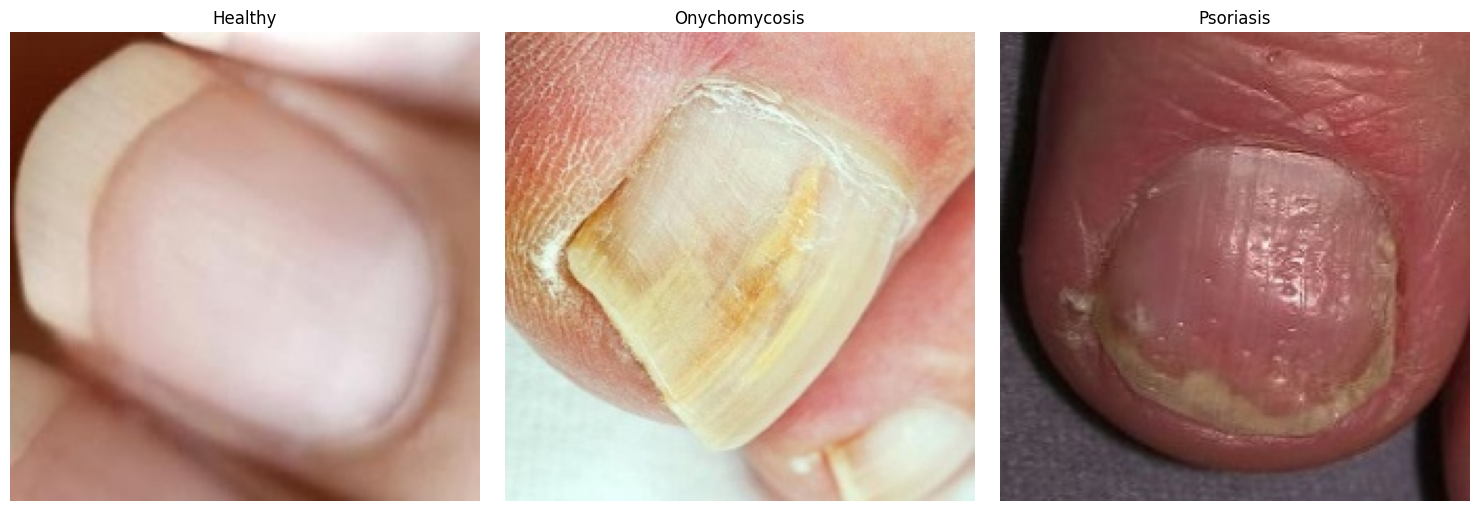

In [9]:
#Step_8:Random Viwer
classes = sorted(final_clean["class_name"].unique())
fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 5))
if len(classes) == 1:
    axes = [axes]

for ax, cls in zip(axes, classes):
    row = final_clean[final_clean["class_name"] == cls].sample(1).iloc[0]
    img = cv2.imread(row["final_path"])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()